# Pipeline 1 — regime-aware shrinkage GMV

## TL;DR

The original five-restart, two-state HMM and probability-weighted covariance pooling are retained. This notebook corrects portfolio accounting and evaluates the same frozen specification on validation and test.

**Executed test result (2021-01-04–2026-02-20):** CAGR 9.68%; annual volatility 13.04%; daily CVaR95 1.84%; maximum drawdown 18.23%; annual two-sided turnover 4.30. Interpret these together with the incremental comparisons and uncertainty below.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/portfolio-mpl")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The supplied 50 stocks were selected using full-history coverage and alphabetical tie-breaking. Historical delistings and index membership are missing. **Survivorship and universe-selection bias remain.** The data represent a narrow US equity sample, not an emerging market.
6. The original baseline notebook already exposed test results. This test is held out for the **new** hyperparameter choices; it is not a pristine preregistered replication. Previously reported numbers are superseded by the common corrected engine.

## Data

### Shared data and prior-only market snapshots

In [2]:
c = prepare_context()
display(c["summary"])
display(pd.DataFrame({"check": ["Price cells", "Missing prices", "Nonpositive prices", "Absolute daily returns > 20%"],
                      "value": [c["prices"].size, int(c["prices"].isna().sum().sum()), int(c["prices"].le(0).sum().sum()), int(c["returns"].abs().gt(.2).sum().sum())]}))
print("Common allocation settings:", asdict(CONFIG))

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,50,213850
validation,2017-01-03,2020-12-31,1007,50,50350
test,2021-01-04,2026-02-20,1289,50,64450


,check,value
0,Price cells,328650
1,Missing prices,0
2,Nonpositive prices,0
3,Absolute daily returns > 20%,271


### Inspect the market-state signals

The HMM uses an equal-weight market return, 20-day realized volatility, 63-day drawdown and 60-day mean pairwise correlation. Features are standardized inside each rolling HMM estimation window, never over the full sample.

,count,mean,std,min,25%,50%,75%,max
market_return,6513.0,0.000627,0.013204,-0.126274,-0.005092,0.000943,0.006744,0.116910
realized_volatility,6513.0,0.176309,0.116015,0.034976,0.107027,0.144236,0.205279,1.054555
drawdown,6513.0,-0.037229,0.053203,-0.467568,-0.049415,-0.017550,-0.003411,0.000000
average_correlation,6513.0,0.319288,0.130390,0.045307,0.221184,0.308582,0.384591,0.774309


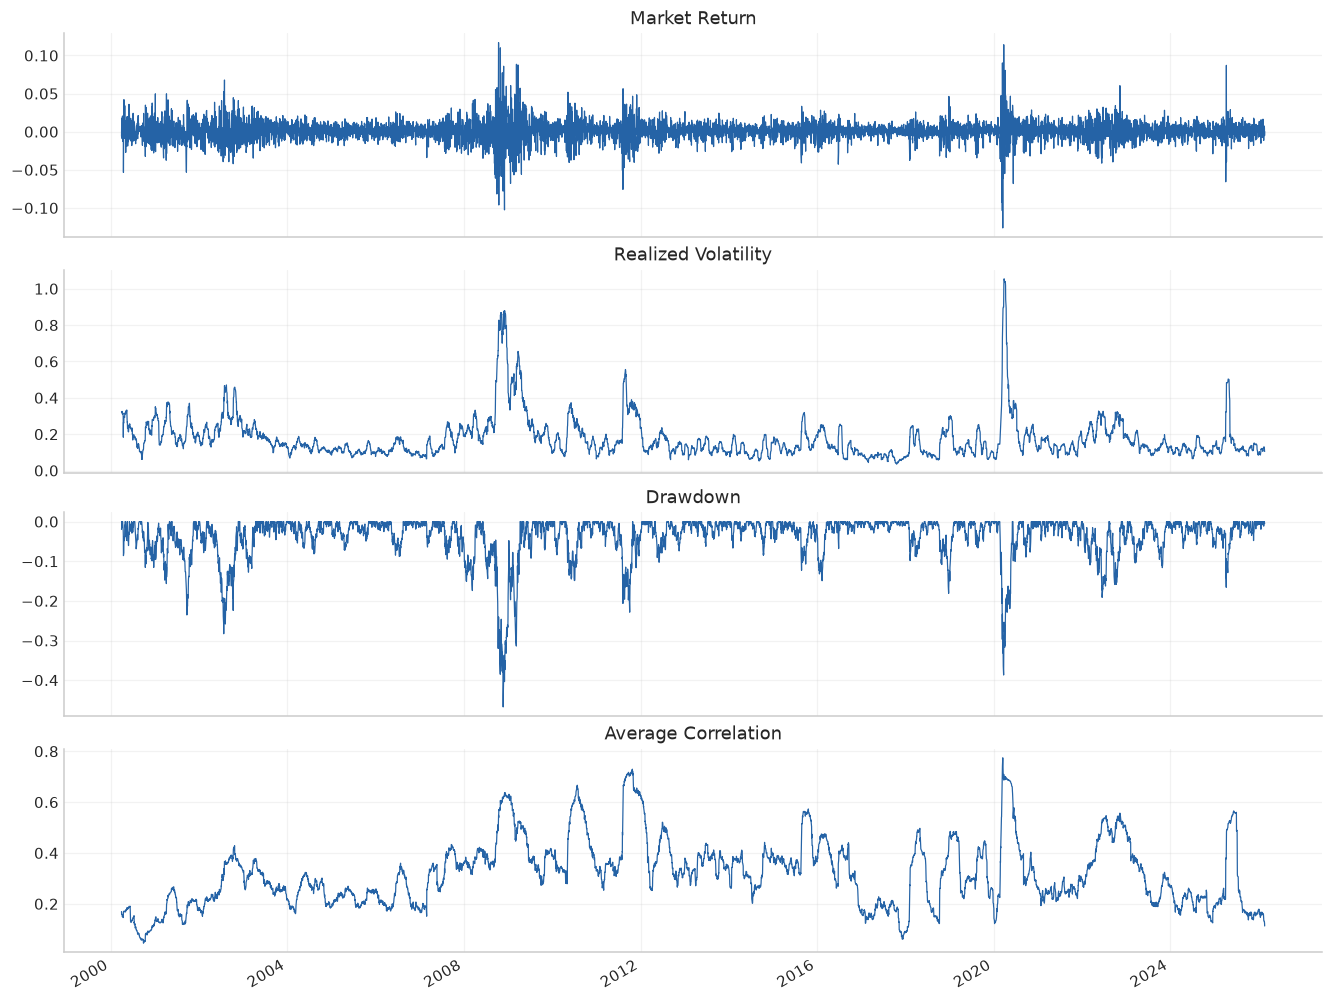

In [3]:
display(c["regime_features"].describe().T)
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, layout="constrained")
for ax, feature in zip(axes, c["regime_features"].columns):
    c["regime_features"][feature].plot(ax=ax, color="#2563a6", lw=.8)
    ax.set(title=feature.replace("_", " ").title(), xlabel="")
save(fig, "pipeline1_market_features")

### Probability-weighted covariance construction

Each state covariance is pooled toward the ordinary shrinkage covariance with `alpha_k = n_eff / (n_eff + N)`. State probabilities are propagated for 21 trading days and averaged. The final covariance mixes these pooled matrices. Historical responsibilities can use observations already known at formation; the final state probability is filtered at that boundary. The state model is re-estimated at every monthly formation using up to 2,520 prior feature observations.

,forecast_stress_probability,calm_effective_observations,stress_effective_observations,regime_condition_number
2025-03-03,0.185338,205.364204,51.62259,139.293732
2025-04-01,0.766828,183.990707,75.032151,189.920532
2025-05-01,0.770713,174.87135,82.732335,381.22794
2025-06-02,0.749501,160.09374,96.558996,371.976705
2025-07-01,0.166349,161.558232,96.888903,206.575288
2025-08-01,0.176713,160.858002,97.603764,209.08013
2025-09-02,0.153739,169.084346,89.803251,191.605131
2025-10-01,0.15255,168.108095,90.502611,174.467955
2025-11-03,0.151695,169.006497,89.877836,184.133913
2025-12-01,0.144943,169.496706,88.209483,198.079365


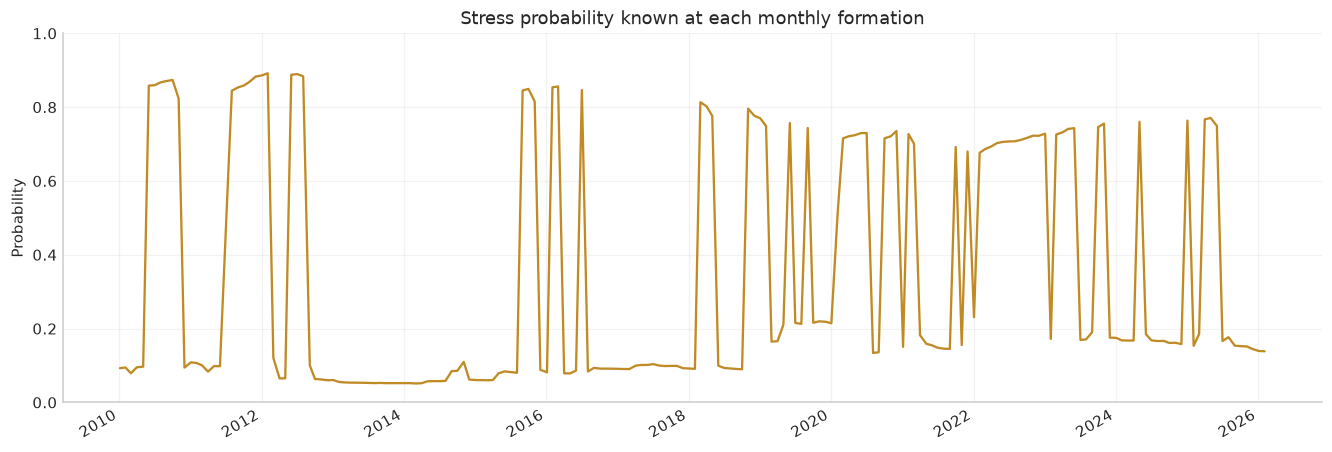

In [4]:
regime_diagnostics = pd.DataFrame({date: m["diagnostics"] for date, m in c["market"].items()}).T
regime_diagnostics.index = pd.DatetimeIndex(regime_diagnostics.index)
display(regime_diagnostics[["forecast_stress_probability", "calm_effective_observations", "stress_effective_observations", "regime_condition_number"]].tail(12))
fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
regime_diagnostics.forecast_stress_probability.astype(float).plot(ax=ax, color="#c08a24")
ax.set(title="Stress probability known at each monthly formation", ylabel="Probability", ylim=(0, 1))
save(fig, "pipeline1_formation_probabilities")

## Results

### Validation and test use the same HMM settings

In [5]:
validation_results = {name: strategy(c, "validation", name) for name in ["baseline", "pipeline1"]}
test_results = {name: strategy(c, "test", name) for name in ["baseline", "pipeline1"]}
for split, results in [("validation", validation_results), ("test", test_results)]:
    display(Markdown(f"**{split.title()}**")); display(styled(metric_table(results)[METRIC_COLUMNS]))
    for name, result in results.items(): export_result(result, name, split)
test_table = metric_table(test_results)

**Validation**

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
baseline,15.42%,18.31%,0.876,1.213,33.51%,2.82%,5.77%,3.302,12.989
pipeline1,16.31%,18.44%,0.912,1.272,32.07%,2.81%,5.74%,4.526,11.567


**Test**

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
baseline,9.16%,13.15%,0.733,1.043,18.63%,1.86%,2.88%,3.235,12.408
pipeline1,9.68%,13.04%,0.774,1.102,18.23%,1.84%,2.84%,4.297,11.585


### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

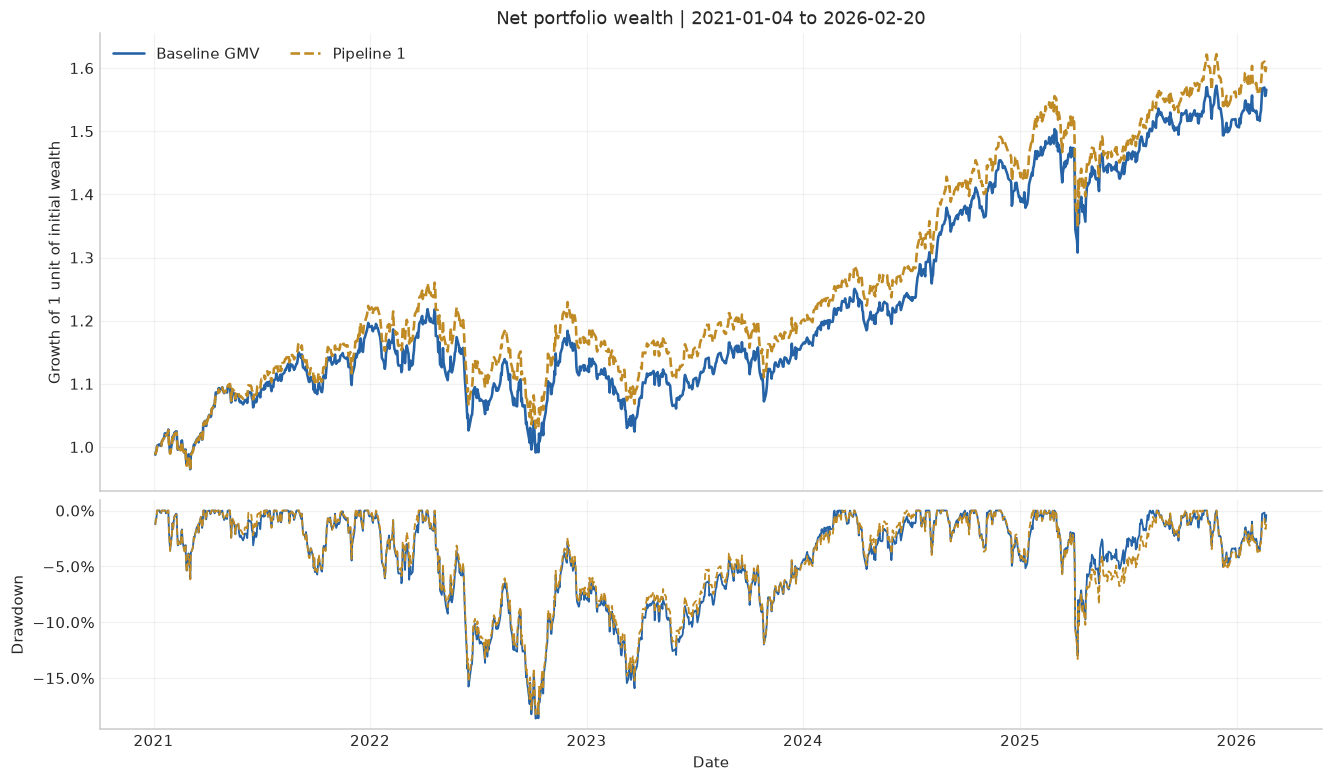

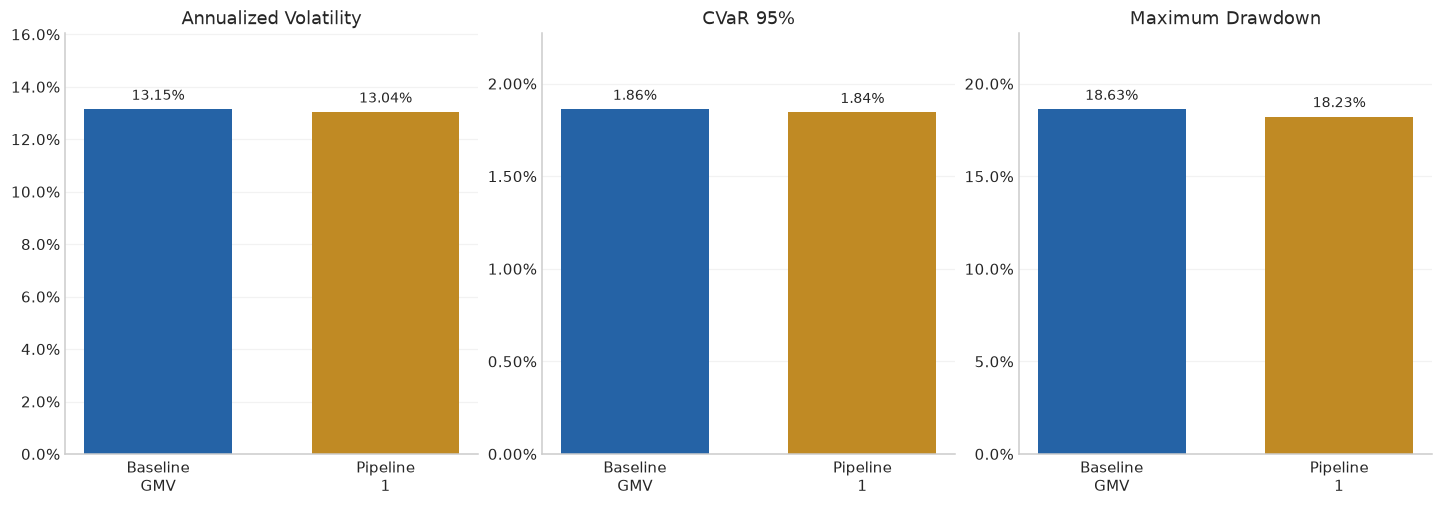

In [6]:
performance_plot(test_results, "pipeline1_test_performance")
risk_plot(test_table, "pipeline1_test_risk")

### Implementation cost and allocation structure

,Annualized Turnover,Total Transaction Costs,Average HHI,Average Effective Assets,Mean Target L1 Change,Solver Failures,HMM Fallbacks
baseline,3.235,1.65%,8.49%,12.408,0.249,0.000,0.000
pipeline1,4.297,2.20%,9.00%,11.585,0.337,0.000,0.000


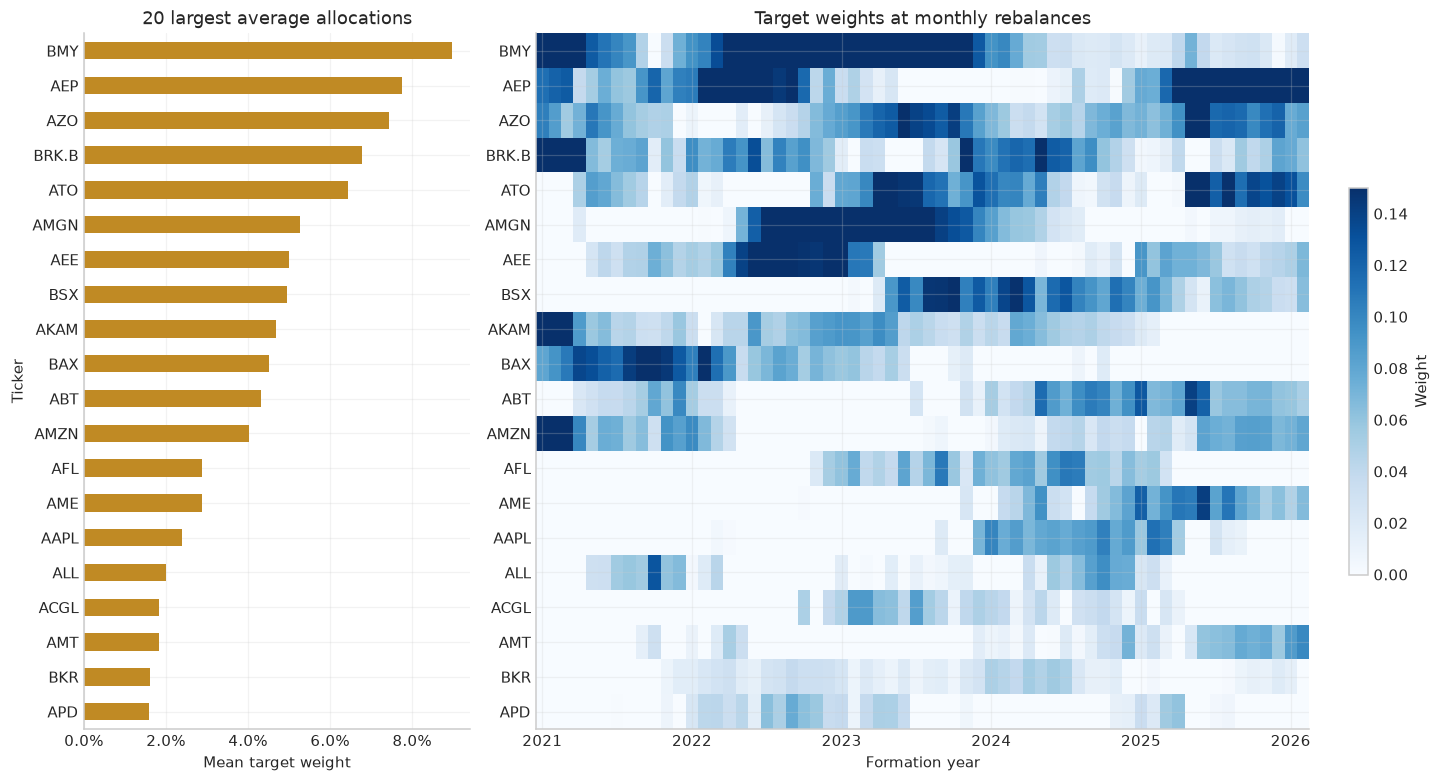

In [7]:
display(styled(test_table[["Annualized Turnover", "Total Transaction Costs", "Average HHI", "Average Effective Assets", "Mean Target L1 Change", "Solver Failures", "HMM Fallbacks"]]))
allocation_plot(test_results["pipeline1"], "pipeline1_test_weights")

### Performance conditional on a previously forecast regime

Dates are classified by the stress probability available at their most recent rebalance. This avoids labelling past observations with a model fitted using their future. Annualization within subsets is descriptive; regime rows are not separate investable portfolios.

In [8]:
conditional = regime_conditioned(test_results)
display(styled(conditional.set_index(["strategy", "regime"])))
uncertainty = paired_bootstrap(test_results["baseline"].returns.net_return, test_results["pipeline1"].returns.net_return)
display(uncertainty)

,difference,lower_95,upper_95
Annualized Volatility,-0.001042,-0.002170,-0.000042
CVaR 95%,-0.000171,-0.000537,0.000111
Maximum Drawdown,-0.003959,-0.026773,0.010606
Sharpe,0.040871,-0.036839,0.134689


## Takeaways

In [9]:
b, p = test_table.loc["baseline"], test_table.loc["pipeline1"]
display(Markdown(f"""Relative to the baseline, Pipeline 1 changes annual volatility by **{(p['Annualized Volatility']-b['Annualized Volatility'])*100:+.2f} percentage points**, daily CVaR95 by **{(p['CVaR 95%']-b['CVaR 95%'])*100:+.3f} points**, and maximum drawdown by **{(p['Maximum Drawdown']-b['Maximum Drawdown'])*100:+.2f} points**. Annual turnover changes from {b['Annualized Turnover']:.2f} to {p['Annualized Turnover']:.2f}. Regime conditioning must be judged through these incremental results and their uncertainty, not through model complexity alone."""))
print("HMM estimation failures are fail-fast; no silent baseline fallback was used.")

Relative to the baseline, Pipeline 1 changes annual volatility by **-0.10 percentage points**, daily CVaR95 by **-0.017 points**, and maximum drawdown by **-0.40 points**. Annual turnover changes from 3.23 to 4.30. Regime conditioning must be judged through these incremental results and their uncertainty, not through model complexity alone.

## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): original selection and saved splits are preserved. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.